In [2]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context
response = urllib.request.urlopen('https://example.com')


In [7]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [9]:
X,Y = mnist.data, mnist.target
X.shape

(70000, 784)

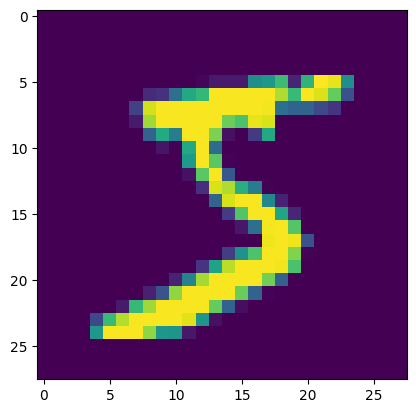

In [8]:
def plot_image(image):
    image = image.reshape(28,-1)
    plt.imshow(image)
    plt.show()
plot_image(X[0])

In [17]:
from sklearn.model_selection import train_test_split

train_x, test_x,train_y,test_y = train_test_split(X,Y,test_size=0.2,random_state = 42)

In [27]:
train_y[:10] == '5'

array([ True, False, False, False, False, False,  True, False, False,
       False])

In [18]:
train_x.shape

(56000, 784)

In [28]:
# 5 binary classifier
train_y_5 = (train_y=='5')
test_y_5 = (test_y=='5')

In [33]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)

sgd_clf = sgd_clf.fit(train_x, train_y_5)

In [39]:
# train_y_5[:10]
some_digit = test_x[10:20]
somedigit_y = test_y_5[10:20]

In [40]:
predicty = sgd_clf.predict(some_digit)

In [41]:
predicty,somedigit_y

(array([False, False, False, False, False,  True, False, False, False,
        False]),
 array([False, False, False, False, False,  True, False, False, False,
        False]))

In [38]:
test_y_5[:10]

array([False, False, False, False, False, False, False, False, False,
       False])

In [43]:
from sklearn.model_selection import cross_val_score
cross_val_scores = cross_val_score(sgd_clf,train_x,train_y_5,cv=3,scoring="accuracy")
cross_val_scores

array([0.97192907, 0.96855413, 0.96024858])

In [44]:
# check_confucion_matrix
from sklearn.model_selection import cross_val_predict
cross_val_predicts = cross_val_predict(sgd_clf,train_x,train_y_5,cv=3)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(train_y_5,cross_val_predicts)

# f

NameError: name 'f' is not defined

In [45]:
cm

array([[50287,   673],
       [ 1180,  3860]])